In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
df=pd.read_csv("Africa Co2 clean data.csv")

In [4]:
df.shape

(1248, 20)

In [5]:
# Check exact column names
print(df.columns.tolist())

['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'co2', 'co2_growth_prct', 'co2_per_capita', 'co2_per_gdp', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'methane', 'oil_co2', 'share_global_co2', 'Continent', 'Region', 'Unnamed: 18', 'Unnamed: 19']


In [6]:
# Remove empty unnamed columns
df = df.drop(columns=['Unnamed: 18', 'Unnamed: 19'])

# Verify fix
print("Cleaned shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Cleaned shape: (1248, 18)
Columns: ['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'co2', 'co2_growth_prct', 'co2_per_capita', 'co2_per_gdp', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'methane', 'oil_co2', 'share_global_co2', 'Continent', 'Region']

First 3 rows:


,country,year,iso_code,population,gdp,cement_co2,co2,co2_growth_prct,co2_per_capita,co2_per_gdp,energy_per_capita,energy_per_gdp,flaring_co2,methane,oil_co2,share_global_co2,Continent,Region
0,Algeria,2000,DZA,30903895,2.085540e+11,3.789,85.399,-6.616,2.763,0.409,9746.524,1.438,14.287,90.853,26.828,0.335,Africa,North Africa
1,Algeria,2001,DZA,31331226,2.234200e+11,3.766,86.839,1.687,2.772,0.389,9961.640,1.391,11.490,80.836,28.458,0.338,Africa,North Africa
2,Algeria,2002,DZA,31750833,2.453610e+11,4.058,90.692,4.437,2.856,0.370,10180.350,1.312,9.878,77.021,29.495,0.345,Africa,North Africa


In [7]:
# Basic data overview
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Countries: {df['country'].nunique()}")
print(f"Years: {df['year'].min()} to {df['year'].max()}")
print(f"\nColumn Names and Data Types:")
print(df.dtypes)

DATASET OVERVIEW
Rows: 1248
Columns: 18
Countries: 52
Years: 2000 to 2023

Column Names and Data Types:
country               object
year                   int64
iso_code              object
population             int64
gdp                  float64
cement_co2           float64
co2                  float64
co2_growth_prct      float64
co2_per_capita       float64
co2_per_gdp          float64
energy_per_capita    float64
energy_per_gdp       float64
flaring_co2          float64
methane              float64
oil_co2              float64
share_global_co2     float64
Continent             object
Region                object
dtype: object


In [8]:
# ============================================================
# STEP 4: DESCRIPTIVE STATISTICS
# Confirm our Excel findings using Python
# ============================================================

print("="*50)
print("DESCRIPTIVE STATISTICS")
print("="*50)

# Select only numeric columns
numeric_cols = ['co2', 'co2_per_capita', 'co2_growth_prct',
                'co2_per_gdp', 'gdp', 'population',
                'cement_co2', 'flaring_co2', 'oil_co2',
                'methane', 'energy_per_capita', 
                'energy_per_gdp', 'share_global_co2']

stats_table = df[numeric_cols].describe().round(3)
print(stats_table)

# Save to CSV
stats_table.to_csv('descriptive_statistics.csv')
print("\nDescriptive statistics saved!")

DESCRIPTIVE STATISTICS
            co2  co2_per_capita  co2_growth_prct  co2_per_gdp           gdp  \
count  1248.000        1248.000         1248.000     1104.000  1.104000e+03   
mean     23.362           1.145            4.524        0.197  9.113353e+10   
std      69.301           1.904           12.367        0.153  2.021928e+11   
min       0.048           0.022          -55.097        0.032  3.128536e+08   
25%       0.727           0.134           -1.386        0.098  7.475460e+09   
50%       3.061           0.344            3.665        0.166  2.179188e+10   
75%       8.555           1.114            9.481        0.235  6.420793e+10   
max     494.698          10.969          126.959        1.065  1.460427e+12   

         population  cement_co2  flaring_co2   oil_co2   methane  \
count  1.248000e+03    1183.000     1248.000  1248.000  1248.000   
mean   2.122687e+07       1.225        1.347     8.498    26.839   
std    3.135464e+07       3.040        4.573    17.785    40.

MISSING VALUES ANALYSIS
                   Missing Count  Missing Percentage (%)
energy_per_gdp               188                   15.06
co2_per_gdp                  144                   11.54
gdp                          144                   11.54
energy_per_capita            108                    8.65
cement_co2                    65                    5.21


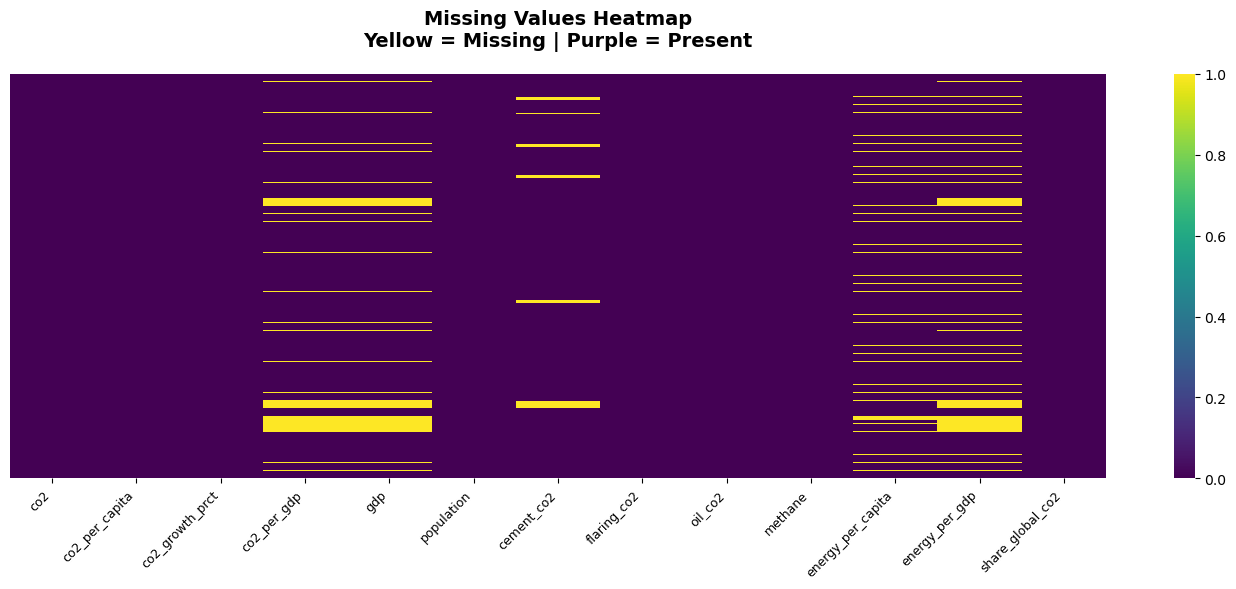

Missing values heatmap saved!


In [9]:
# ============================================================
# STEP 5: MISSING VALUES ANALYSIS
# Visualize where data gaps exist across all variables
# ============================================================

print("="*50)
print("MISSING VALUES ANALYSIS")
print("="*50)

# Count and percentage of missing values
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_pct
}).sort_values('Missing Percentage (%)', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing values as heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(df[numeric_cols].isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis',
            xticklabels=numeric_cols)

plt.title('Missing Values Heatmap\nYellow = Missing | Purple = Present',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('01_missing_values_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Missing values heatmap saved!")

OUTLIER DETECTION


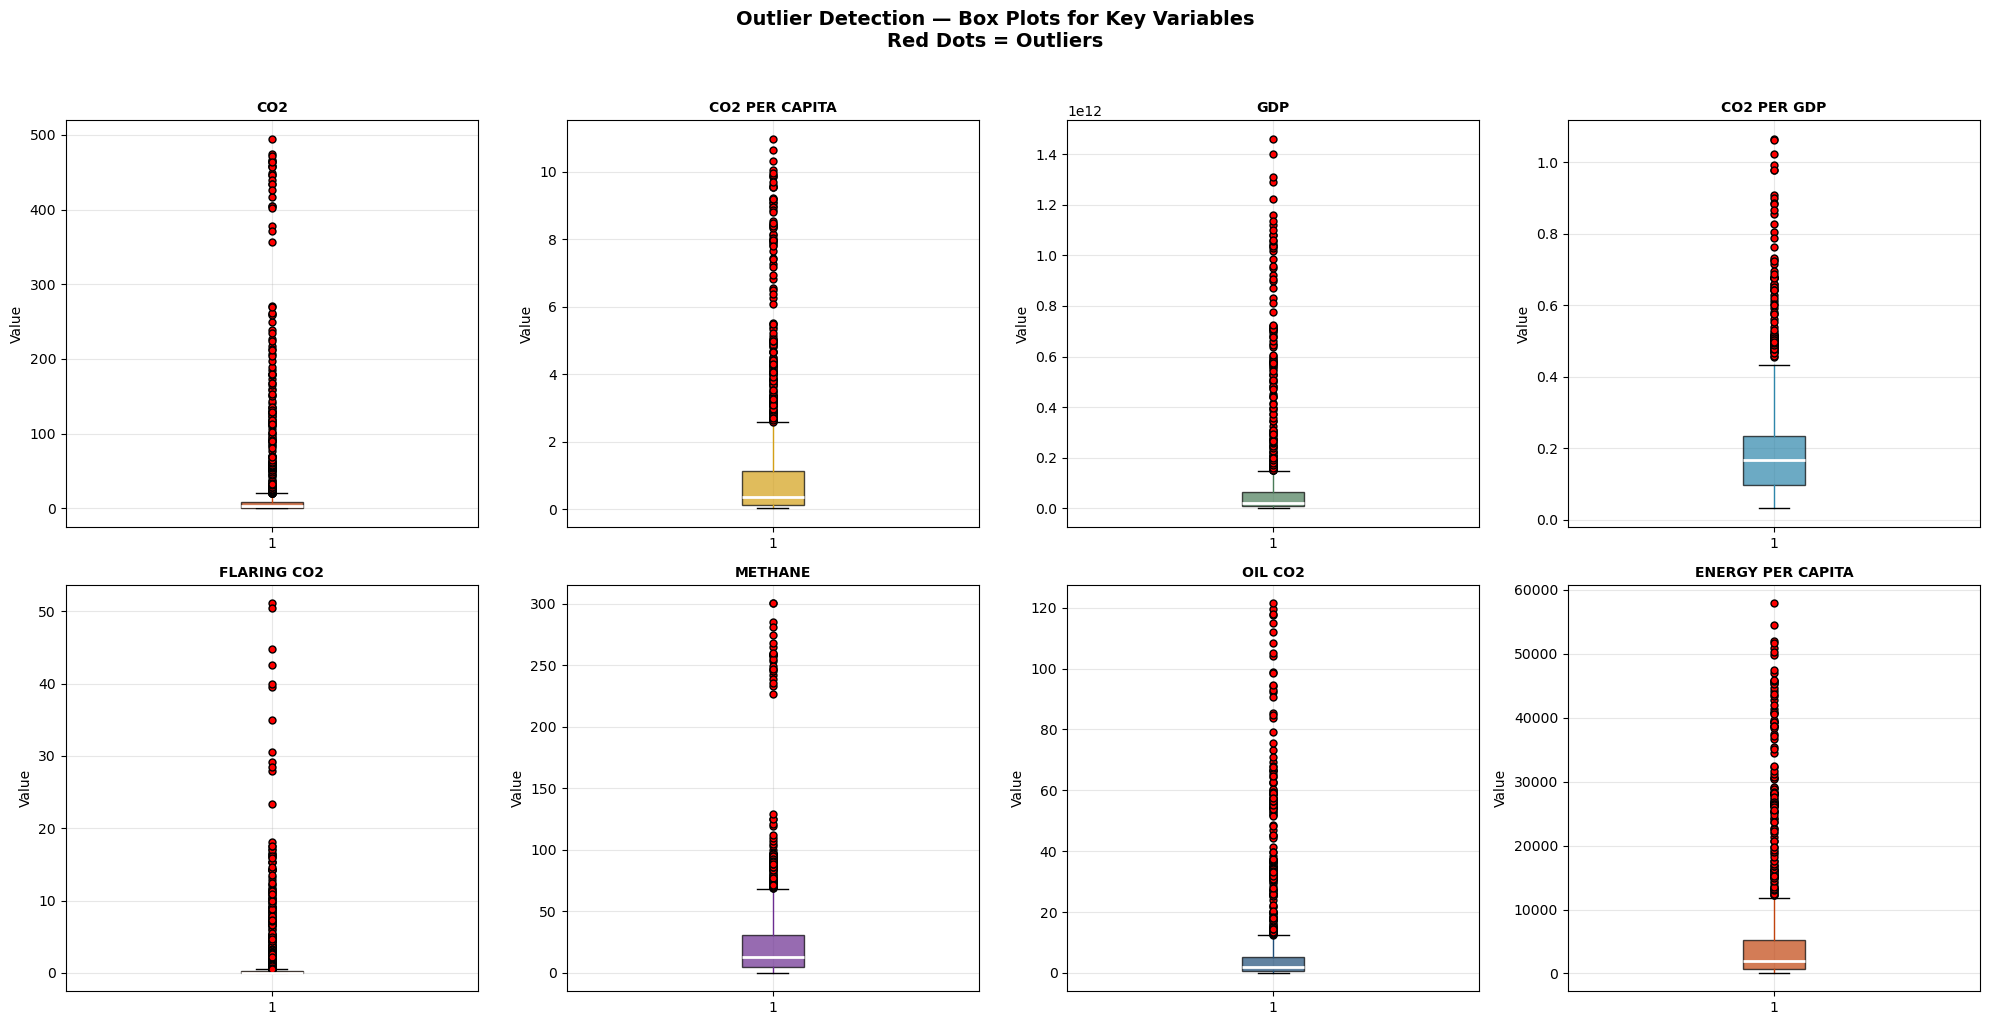


OUTLIER COUNTRIES BY VARIABLE:

Top outliers for co2:
country
South Africa    436.88
Egypt           207.71
Algeria         134.33
Nigeria         111.34
Libya            56.83
Name: co2, dtype: float64

Top outliers for flaring_co2:
country
Nigeria    25.50
Algeria    13.69
Libya       8.00
Angola      6.88
Egypt       3.88
Name: flaring_co2, dtype: float64

Top outliers for co2_per_capita:
country
Libya                9.00
South Africa         8.12
Equatorial Guinea    4.75
Seychelles           4.47
Gabon                3.75
Name: co2_per_capita, dtype: float64

Top outliers for methane:
country
Nigeria         258.41
Ethiopia         99.41
South Africa     92.38
Algeria          87.62
Egypt            74.85
Name: methane, dtype: float64

Outlier detection complete!


In [10]:
# ============================================================
# STEP 6: OUTLIER DETECTION
# Box plots to formally identify outlier countries
# Using IQR method as planned in methodology
# ============================================================

print("="*50)
print("OUTLIER DETECTION")
print("="*50)

# Variables to check for outliers
outlier_cols = ['co2', 'co2_per_capita', 'gdp',
                'co2_per_gdp', 'flaring_co2', 'methane',
                'oil_co2', 'energy_per_capita']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

colors = ['#C1440E', '#D4A017', '#4A7C59', '#2E86AB',
          '#8B4513', '#6B2C91', '#1F4E79', '#C1440E']

for i, col in enumerate(outlier_cols):
    if col in df.columns:
        axes[i].boxplot(
            df[col].dropna(),
            patch_artist=True,
            boxprops=dict(facecolor=colors[i], alpha=0.7),
            medianprops=dict(color='white', linewidth=2),
            whiskerprops=dict(color=colors[i]),
            flierprops=dict(marker='o',
                           markerfacecolor='red',
                           markersize=5))
        axes[i].set_title(col.replace('_', ' ').upper(),
                         fontsize=10, fontweight='bold')
        axes[i].set_ylabel('Value')
        axes[i].grid(True, alpha=0.3)

plt.suptitle('Outlier Detection — Box Plots for Key Variables\nRed Dots = Outliers',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_outlier_detection_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# Identify specific outlier countries using IQR method
print("\nOUTLIER COUNTRIES BY VARIABLE:")
print("="*50)

for col in ['co2', 'flaring_co2', 'co2_per_capita', 'methane']:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        upper = Q3 + (1.5 * IQR)
        outliers = df[df[col] > upper][['country', col]]\
                   .groupby('country')[col].mean()\
                   .sort_values(ascending=False).head(5)
        print(f"\nTop outliers for {col}:")
        print(outliers.round(2))

print("\nOutlier detection complete!")

CORRELATION ANALYSIS
Correlation Matrix:
                    co2  co2_per_capita  co2_growth_prct  co2_per_gdp   gdp  \
co2                1.00            0.59            -0.06         0.55  0.77   
co2_per_capita     0.59            1.00            -0.05         0.72  0.31   
co2_growth_prct   -0.06           -0.05             1.00        -0.03 -0.06   
co2_per_gdp        0.55            0.72            -0.03         1.00  0.22   
gdp                0.77            0.31            -0.06         0.22  1.00   
population         0.45           -0.02            -0.01        -0.06  0.77   
flaring_co2        0.27            0.22            -0.03         0.17  0.47   
methane            0.50            0.13            -0.02         0.11  0.73   
oil_co2            0.79            0.44            -0.03         0.34  0.94   
energy_per_capita  0.38            0.86            -0.08         0.52  0.19   
share_global_co2   0.99            0.59            -0.05         0.58  0.74   

          

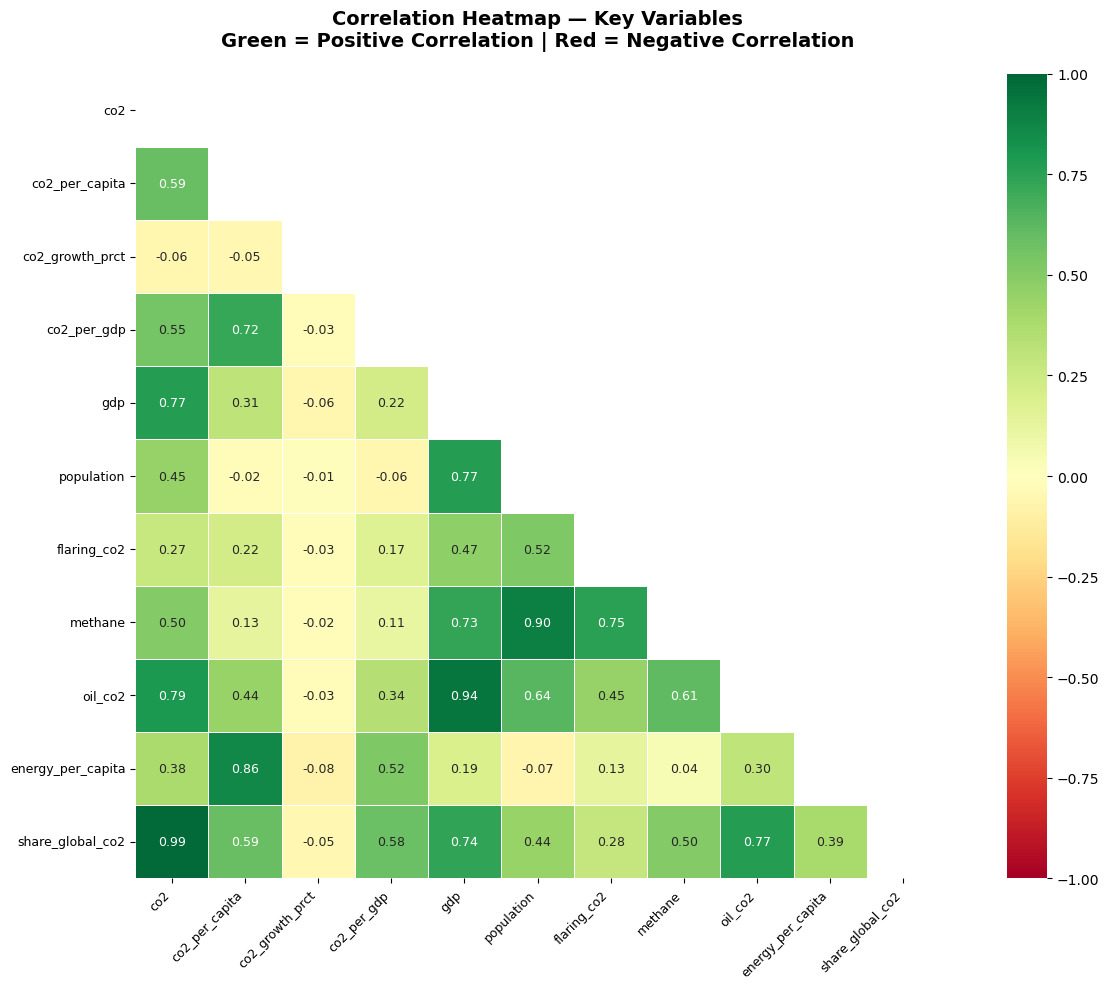

Correlation heatmap saved!


In [11]:
# ============================================================
# STEP 7: CORRELATION ANALYSIS
# Heatmap showing relationships between all variables
# Green = strong positive | Red = strong negative
# ============================================================

print("="*50)
print("CORRELATION ANALYSIS")
print("="*50)

# Calculate correlation matrix
corr_cols = ['co2', 'co2_per_capita', 'co2_growth_prct',
             'co2_per_gdp', 'gdp', 'population',
             'flaring_co2', 'methane', 'oil_co2',
             'energy_per_capita', 'share_global_co2']

corr_cols = [col for col in corr_cols if col in df.columns]
corr_matrix = df[corr_cols].corr().round(2)

print("Correlation Matrix:")
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(14, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 9},
            mask=mask)

plt.title('Correlation Heatmap — Key Variables\n'
          'Green = Positive Correlation | Red = Negative Correlation',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('03_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved!")

GDP vs CO2 CORRELATION — CORE FINDING
Pearson Correlation Coefficient (r): 0.7712
P-value: 0.000000

Interpretation:
There is a STRONG POSITIVE correlation between GDP and CO2
Result is STATISTICALLY SIGNIFICANT (p < 0.05)
We can confidently say GDP and CO2 are related


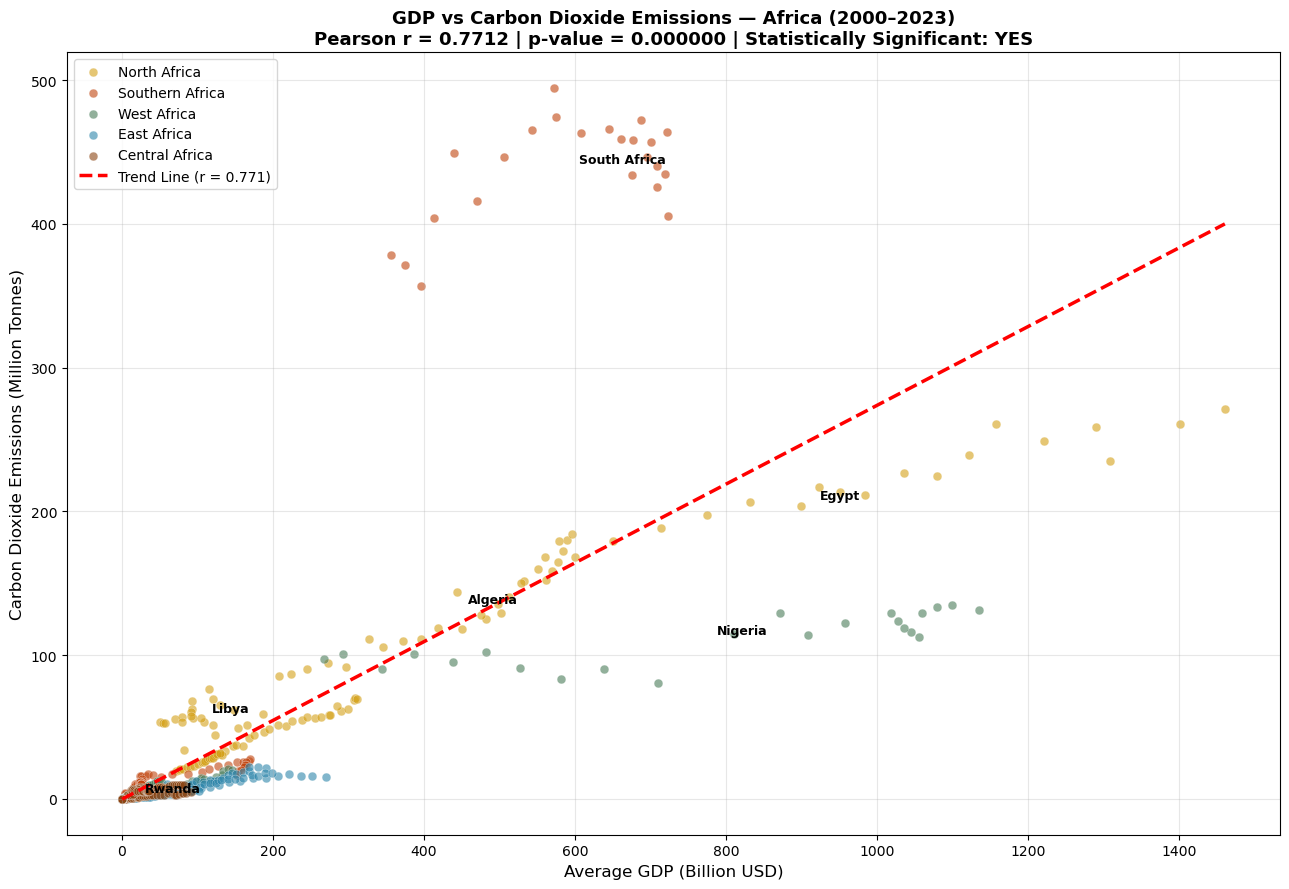


GDP vs CO2 scatter plot saved!
KEY RESULT: r = 0.7712


In [12]:
# ============================================================
# STEP 8: GDP vs CO2 PEARSON CORRELATION
# This is the core statistical test of the project
# It answers: Is GDP the primary driver of CO2 emissions?
# ============================================================

print("="*50)
print("GDP vs CO2 CORRELATION — CORE FINDING")
print("="*50)

# Drop missing values
gdp_co2 = df[['country', 'year', 'gdp', 'co2', 'Region']].dropna()

# Calculate Pearson correlation
correlation, p_value = stats.pearsonr(gdp_co2['gdp'], gdp_co2['co2'])

print(f"Pearson Correlation Coefficient (r): {correlation:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"\nInterpretation:")

if abs(correlation) > 0.7:
    strength = "STRONG"
elif abs(correlation) > 0.4:
    strength = "MODERATE"
else:
    strength = "WEAK"

direction = "POSITIVE" if correlation > 0 else "NEGATIVE"
print(f"There is a {strength} {direction} correlation between GDP and CO2")

if p_value < 0.05:
    print("Result is STATISTICALLY SIGNIFICANT (p < 0.05)")
    print("We can confidently say GDP and CO2 are related")
else:
    print("Result is NOT statistically significant (p > 0.05)")

# Scatter plot with regression line
plt.figure(figsize=(13, 9))

region_colors = {
    'North Africa': '#D4A017',
    'Southern Africa': '#C1440E',
    'West Africa': '#4A7C59',
    'East Africa': '#2E86AB',
    'Central Africa': '#8B4513'
}

for region, color in region_colors.items():
    mask = gdp_co2['Region'] == region
    plt.scatter(gdp_co2[mask]['gdp'] / 1e9,
               gdp_co2[mask]['co2'],
               c=color, label=region,
               alpha=0.6, s=40,
               edgecolors='white', linewidth=0.3)

# Regression line
z = np.polyfit(gdp_co2['gdp'] / 1e9, gdp_co2['co2'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(gdp_co2['gdp'].min() / 1e9,
                     gdp_co2['gdp'].max() / 1e9, 100)
plt.plot(x_line, p_line(x_line), "r--",
         linewidth=2.5,
         label=f'Trend Line (r = {correlation:.3f})')

# Labels for key countries
key_countries = ['South Africa', 'Nigeria', 'Egypt',
                 'Rwanda', 'Libya', 'Algeria']
for country in key_countries:
    country_data = gdp_co2[gdp_co2['country'] == country]
    if not country_data.empty:
        avg_gdp = country_data['gdp'].mean() / 1e9
        avg_co2 = country_data['co2'].mean()
        plt.annotate(country,
                    xy=(avg_gdp, avg_co2),
                    xytext=(8, 4),
                    textcoords='offset points',
                    fontsize=9, fontweight='bold',
                    color='black')

plt.xlabel('Average GDP (Billion USD)', fontsize=12)
plt.ylabel('Carbon Dioxide Emissions (Million Tonnes)', fontsize=12)
plt.title(f'GDP vs Carbon Dioxide Emissions — Africa (2000–2023)\n'
          f'Pearson r = {correlation:.4f} | p-value = {p_value:.6f} | '
          f'Statistically Significant: {"YES" if p_value < 0.05 else "NO"}',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('04_gdp_vs_co2_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nGDP vs CO2 scatter plot saved!")
print(f"KEY RESULT: r = {correlation:.4f}")

TREND ANALYSIS (2000-2023)
Year by Year Averages:
    year     co2           gdp  co2_per_capita  co2_per_gdp  co2_growth_prct  \
0   2000  17.750  4.424175e+10           1.064        0.237            2.977   
1   2001  17.535  4.723978e+10           1.075        0.226            4.857   
2   2002  17.143  5.056530e+10           1.033        0.214            2.399   
3   2003  18.910  5.412863e+10           1.083        0.219            9.737   
4   2004  19.949  5.829247e+10           1.161        0.216            5.906   
5   2005  20.207  6.291202e+10           1.156        0.208            2.536   
6   2006  20.832  6.799044e+10           1.146        0.199            4.654   
7   2007  21.331  7.392977e+10           1.103        0.188            3.801   
8   2008  22.442  7.996471e+10           1.133        0.181            1.949   
9   2009  22.337  8.476197e+10           1.108        0.182            5.110   
10  2010  23.258  9.199999e+10           1.176        0.186           

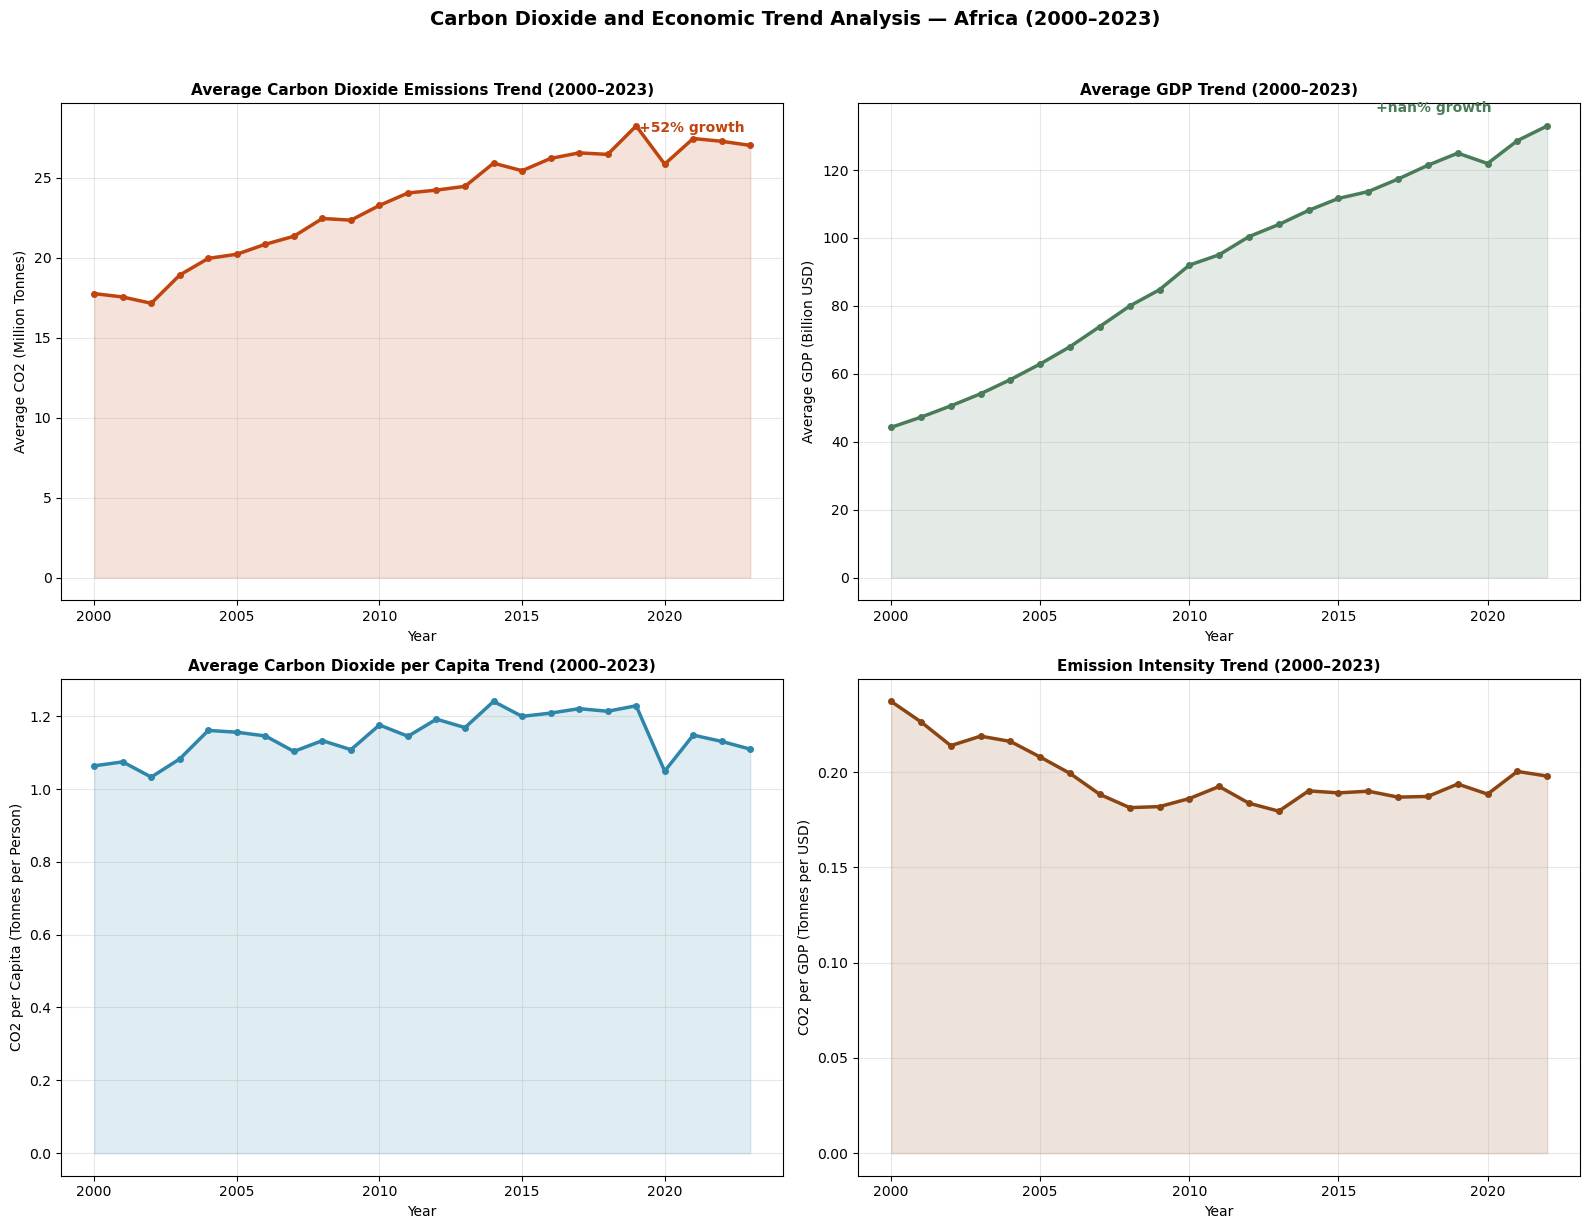

Trend analysis saved!


In [13]:
# ============================================================
# STEP 9: TREND ANALYSIS (2000-2023)
# Line charts showing how variables changed over time
# ============================================================

print("="*50)
print("TREND ANALYSIS (2000-2023)")
print("="*50)

# Calculate yearly averages
yearly = df.groupby('year').agg({
    'co2': 'mean',
    'gdp': 'mean',
    'co2_per_capita': 'mean',
    'co2_per_gdp': 'mean',
    'co2_growth_prct': 'mean',
    'flaring_co2': 'mean'
}).reset_index()

print("Year by Year Averages:")
print(yearly.round(3))

# Calculate overall growth
co2_growth = ((yearly['co2'].iloc[-1] - yearly['co2'].iloc[0]) /
               yearly['co2'].iloc[0] * 100)
gdp_growth = ((yearly['gdp'].iloc[-1] - yearly['gdp'].iloc[0]) /
               yearly['gdp'].iloc[0] * 100)

print(f"\nOverall CO2 Growth (2000-2023): {co2_growth:.1f}%")
print(f"Overall GDP Growth (2000-2023): {gdp_growth:.1f}%")
print(f"GDP grew {gdp_growth/co2_growth:.1f}x faster than CO2")

# Plot 4 trend charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1 - CO2 trend
axes[0,0].plot(yearly['year'], yearly['co2'],
               color='#C1440E', linewidth=2.5,
               marker='o', markersize=4)
axes[0,0].fill_between(yearly['year'], yearly['co2'],
                        alpha=0.15, color='#C1440E')
axes[0,0].set_title('Average Carbon Dioxide Emissions Trend (2000–2023)',
                     fontweight='bold', fontsize=11)
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Average CO2 (Million Tonnes)')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].annotate(f'+{co2_growth:.0f}% growth',
                   xy=(2023, yearly['co2'].iloc[-1]),
                   xytext=(-80, 10),
                   textcoords='offset points',
                   fontsize=10, color='#C1440E',
                   fontweight='bold')

# Chart 2 - GDP trend
axes[0,1].plot(yearly['year'], yearly['gdp'] / 1e9,
               color='#4A7C59', linewidth=2.5,
               marker='o', markersize=4)
axes[0,1].fill_between(yearly['year'], yearly['gdp'] / 1e9,
                        alpha=0.15, color='#4A7C59')
axes[0,1].set_title('Average GDP Trend (2000–2023)',
                     fontweight='bold', fontsize=11)
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Average GDP (Billion USD)')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].annotate(f'+{gdp_growth:.0f}% growth',
                   xy=(2020, yearly['gdp'].iloc[-2] / 1e9),
                   xytext=(-80, 10),
                   textcoords='offset points',
                   fontsize=10, color='#4A7C59',
                   fontweight='bold')

# Chart 3 - CO2 per capita
axes[1,0].plot(yearly['year'], yearly['co2_per_capita'],
               color='#2E86AB', linewidth=2.5,
               marker='o', markersize=4)
axes[1,0].fill_between(yearly['year'], yearly['co2_per_capita'],
                        alpha=0.15, color='#2E86AB')
axes[1,0].set_title('Average Carbon Dioxide per Capita Trend (2000–2023)',
                     fontweight='bold', fontsize=11)
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('CO2 per Capita (Tonnes per Person)')
axes[1,0].grid(True, alpha=0.3)

# Chart 4 - Emission intensity
axes[1,1].plot(yearly['year'], yearly['co2_per_gdp'],
               color='#8B4513', linewidth=2.5,
               marker='o', markersize=4)
axes[1,1].fill_between(yearly['year'], yearly['co2_per_gdp'],
                        alpha=0.15, color='#8B4513')
axes[1,1].set_title('Emission Intensity Trend (2000–2023)',
                     fontweight='bold', fontsize=11)
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('CO2 per GDP (Tonnes per USD)')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Carbon Dioxide and Economic Trend Analysis — Africa (2000–2023)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('05_trend_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Trend analysis saved!")

TOP EMITTERS ANALYSIS
        Country  Average CO2 (Mt)
0  South Africa            436.88
1         Egypt            207.71
2       Algeria            134.33
3       Nigeria            111.34
4         Libya             56.83
5       Morocco             53.76
6       Tunisia             26.88
7        Angola             20.62
8         Sudan             14.96
9         Kenya             14.05


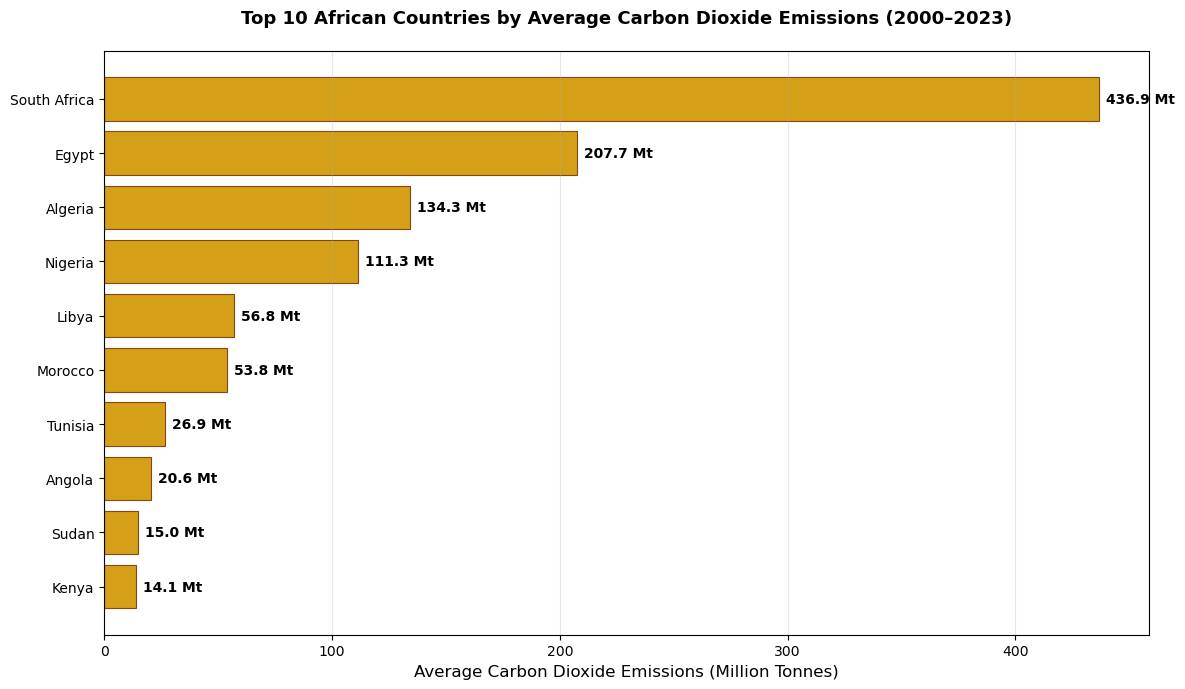

Top emitters chart saved!


In [14]:
# ============================================================
# STEP 10: TOP EMITTERS ANALYSIS
# Bar chart of top 10 countries by average CO2 emissions
# ============================================================

print("="*50)
print("TOP EMITTERS ANALYSIS")
print("="*50)

top_emitters = df.groupby('country')['co2'].mean()\
                 .round(2).sort_values(ascending=False)\
                 .head(10).reset_index()
top_emitters.columns = ['Country', 'Average CO2 (Mt)']
print(top_emitters)

plt.figure(figsize=(12, 7))
bars = plt.barh(top_emitters['Country'][::-1],
                top_emitters['Average CO2 (Mt)'][::-1],
                color='#D4A017',
                edgecolor='#8B4513',
                linewidth=0.8)

for bar, val in zip(bars, top_emitters['Average CO2 (Mt)'][::-1]):
    plt.text(bar.get_width() + 3,
             bar.get_y() + bar.get_height()/2,
             f'{val:.1f} Mt',
             va='center', fontsize=10, fontweight='bold')

plt.xlabel('Average Carbon Dioxide Emissions (Million Tonnes)', fontsize=12)
plt.title('Top 10 African Countries by Average Carbon Dioxide Emissions (2000–2023)',
          fontsize=13, fontweight='bold', pad=20)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('06_top_emitters.png', dpi=300, bbox_inches='tight')
plt.show()
print("Top emitters chart saved!")

REGIONAL COMPARISON
            Region  Avg CO2 (Mt)  Avg GDP (USD)  Avg CO2 per Capita  \
0   Central Africa         3.775   2.495038e+10               1.301   
1      East Africa         3.467   4.478154e+10               0.679   
2     North Africa        82.413   3.594023e+11               3.189   
3  Southern Africa        54.316   9.557074e+10               1.695   
4      West Africa        10.184   6.833741e+10               0.351   

   Avg Emission Intensity  
0                   0.165  
1                   0.122  
2                   0.324  
3                   0.304  
4                   0.163  


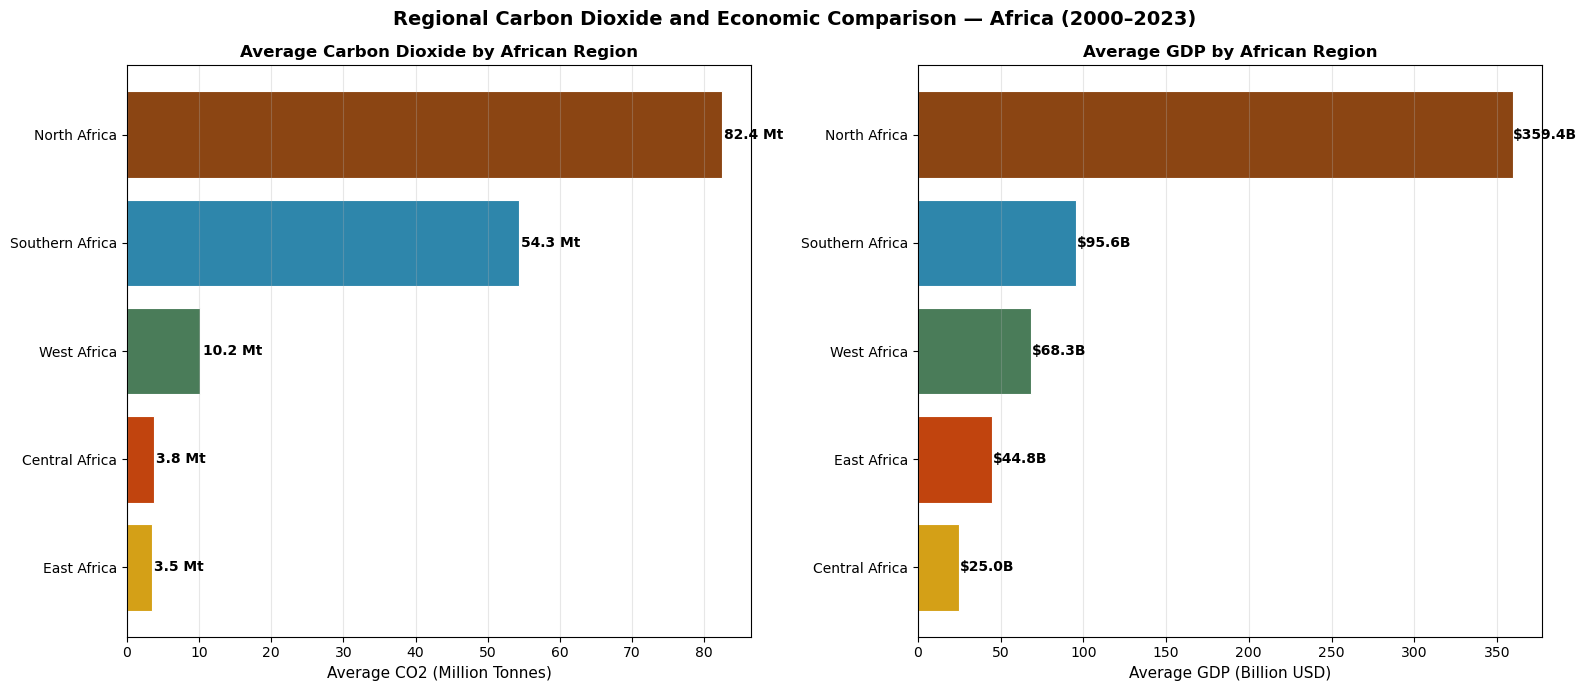

Regional comparison saved!


In [15]:
# ============================================================
# STEP 11: REGIONAL COMPARISON
# Compare all 5 African regions by CO2 and GDP
# ============================================================

print("="*50)
print("REGIONAL COMPARISON")
print("="*50)

regional = df.groupby('Region').agg({
    'co2': 'mean',
    'gdp': 'mean',
    'co2_per_capita': 'mean',
    'co2_per_gdp': 'mean'
}).round(3).reset_index()

regional.columns = ['Region', 'Avg CO2 (Mt)',
                    'Avg GDP (USD)', 'Avg CO2 per Capita',
                    'Avg Emission Intensity']
print(regional)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

region_colors = ['#D4A017', '#C1440E', '#4A7C59',
                 '#2E86AB', '#8B4513']

# CO2 by region
regional_co2 = regional.sort_values('Avg CO2 (Mt)', ascending=True)
bars1 = axes[0].barh(regional_co2['Region'],
                      regional_co2['Avg CO2 (Mt)'],
                      color=region_colors,
                      edgecolor='white', linewidth=0.8)

for bar, val in zip(bars1, regional_co2['Avg CO2 (Mt)']):
    axes[0].text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height()/2,
                f'{val:.1f} Mt',
                va='center', fontsize=10, fontweight='bold')

axes[0].set_xlabel('Average CO2 (Million Tonnes)', fontsize=11)
axes[0].set_title('Average Carbon Dioxide by African Region',
                  fontweight='bold', fontsize=12)
axes[0].grid(True, axis='x', alpha=0.3)

# GDP by region
regional_gdp = regional.sort_values('Avg GDP (USD)', ascending=True)
bars2 = axes[1].barh(regional_gdp['Region'],
                      regional_gdp['Avg GDP (USD)'] / 1e9,
                      color=region_colors,
                      edgecolor='white', linewidth=0.8)

for bar, val in zip(bars2, regional_gdp['Avg GDP (USD)'] / 1e9):
    axes[1].text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height()/2,
                f'${val:.1f}B',
                va='center', fontsize=10, fontweight='bold')

axes[1].set_xlabel('Average GDP (Billion USD)', fontsize=11)
axes[1].set_title('Average GDP by African Region',
                  fontweight='bold', fontsize=12)
axes[1].grid(True, axis='x', alpha=0.3)

plt.suptitle('Regional Carbon Dioxide and Economic Comparison — Africa (2000–2023)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_regional_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Regional comparison saved!")

DECOUPLING ANALYSIS

Country Classification:
Status
Moderate                   24
Decoupling (Efficient)     20
High Risk (Inefficient)     8
Name: count, dtype: int64

Top 10 Decoupling Countries (Most Carbon Efficient):
                         Country  Emission Intensity       Avg GDP  Avg CO2
37                        Rwanda              0.0515  1.604028e+10   0.8640
5                        Burundi              0.0537  6.712807e+09   0.3958
8       Central African Republic              0.0553  3.764266e+09   0.2095
49                        Uganda              0.0554  6.232440e+10   3.6730
12  Democratic Republic of Congo              0.0618  5.232745e+10   3.0719
28                        Malawi              0.0648  1.803699e+10   1.1803
17                      Ethiopia              0.0763  1.274122e+11   9.6618
46                      Tanzania              0.0847  1.073564e+11   9.8143
9                           Chad              0.0873  1.778066e+10   1.6561
27                

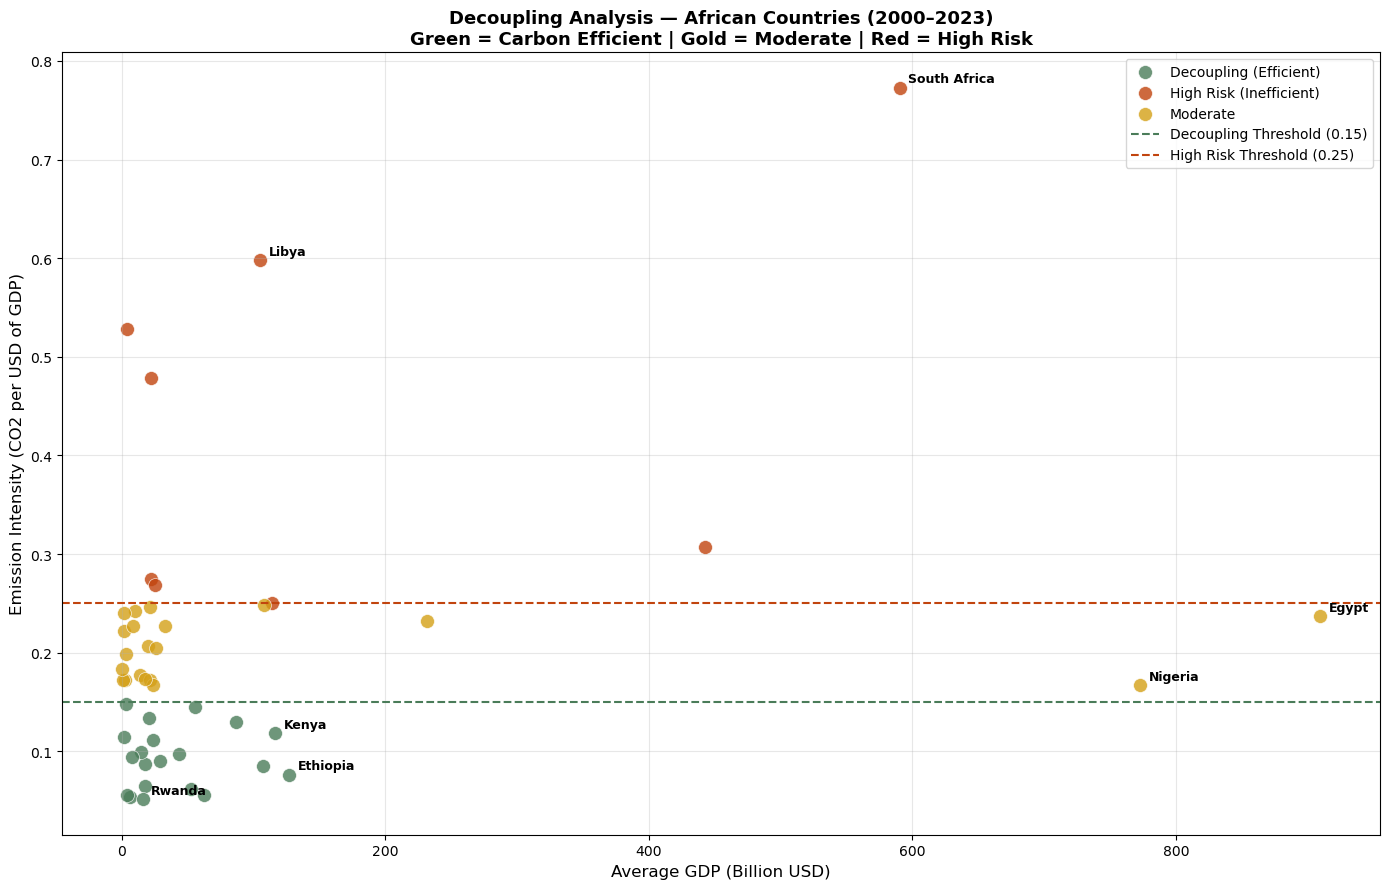

Decoupling analysis saved!


In [16]:
# ============================================================
# STEP 12: DECOUPLING ANALYSIS
# Identify countries where GDP grows faster than CO2
# Decoupling threshold: emission intensity < 0.15
# High risk threshold: CO2 growth > 5% per year
# ============================================================

print("="*50)
print("DECOUPLING ANALYSIS")
print("="*50)

# Calculate country level statistics
country_stats = df.groupby('country').agg({
    'co2_growth_prct': 'mean',
    'co2_per_gdp': 'mean',
    'co2': 'mean',
    'gdp': 'mean'
}).round(4).reset_index()

country_stats.columns = ['Country', 'Avg CO2 Growth %',
                          'Emission Intensity',
                          'Avg CO2', 'Avg GDP']

# Classify countries
country_stats['Status'] = country_stats['Emission Intensity'].apply(
    lambda x: 'Decoupling (Efficient)' if x < 0.15 else
    ('High Risk (Inefficient)' if x > 0.25 else 'Moderate'))

print("\nCountry Classification:")
print(country_stats['Status'].value_counts())

print("\nTop 10 Decoupling Countries (Most Carbon Efficient):")
decoupling = country_stats[
    country_stats['Status'] == 'Decoupling (Efficient)']\
    .sort_values('Emission Intensity')
print(decoupling[['Country', 'Emission Intensity',
                   'Avg GDP', 'Avg CO2']].head(10).round(4))

print("\nTop 10 High Risk Countries (Least Carbon Efficient):")
high_risk = country_stats[
    country_stats['Status'] == 'High Risk (Inefficient)']\
    .sort_values('Emission Intensity', ascending=False)
print(high_risk[['Country', 'Emission Intensity',
                  'Avg CO2 Growth %']].head(10).round(4))

# Scatter plot
plt.figure(figsize=(14, 9))

status_colors = {
    'Decoupling (Efficient)': '#4A7C59',
    'High Risk (Inefficient)': '#C1440E',
    'Moderate': '#D4A017'
}

for status, color in status_colors.items():
    mask = country_stats['Status'] == status
    plt.scatter(
        country_stats[mask]['Avg GDP'] / 1e9,
        country_stats[mask]['Emission Intensity'],
        c=color, label=status,
        s=100, alpha=0.8,
        edgecolors='white', linewidth=0.5)

# Label key countries
key = ['South Africa', 'Nigeria', 'Egypt',
       'Rwanda', 'Libya', 'Ethiopia', 'Kenya']
for _, row in country_stats[
        country_stats['Country'].isin(key)].iterrows():
    plt.annotate(
        row['Country'],
        xy=(row['Avg GDP'] / 1e9, row['Emission Intensity']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=9, fontweight='bold')

# Threshold lines
plt.axhline(y=0.15, color='#4A7C59', linestyle='--',
            linewidth=1.5, label='Decoupling Threshold (0.15)')
plt.axhline(y=0.25, color='#C1440E', linestyle='--',
            linewidth=1.5, label='High Risk Threshold (0.25)')

plt.xlabel('Average GDP (Billion USD)', fontsize=12)
plt.ylabel('Emission Intensity (CO2 per USD of GDP)', fontsize=12)
plt.title('Decoupling Analysis — African Countries (2000–2023)\n'
          'Green = Carbon Efficient | Gold = Moderate | Red = High Risk',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('08_decoupling_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Decoupling analysis saved!")

EMISSION INTENSITY RANKING
Most Carbon Efficient (Top 10):
                        Country  Avg Emission Intensity
0                        Rwanda                  0.0515
1                       Burundi                  0.0537
2      Central African Republic                  0.0553
3                        Uganda                  0.0554
4  Democratic Republic of Congo                  0.0618
5                        Malawi                  0.0648
6                      Ethiopia                  0.0763
7                      Tanzania                  0.0847
8                          Chad                  0.0873
9                    Madagascar                  0.0900

Least Carbon Efficient (Bottom 10):
              Country  Avg Emission Intensity
38              Congo                  0.2461
39            Tunisia                  0.2479
40             Angola                  0.2505
41              Gabon                  0.2690
42  Equatorial Guinea                  0.2744
43          

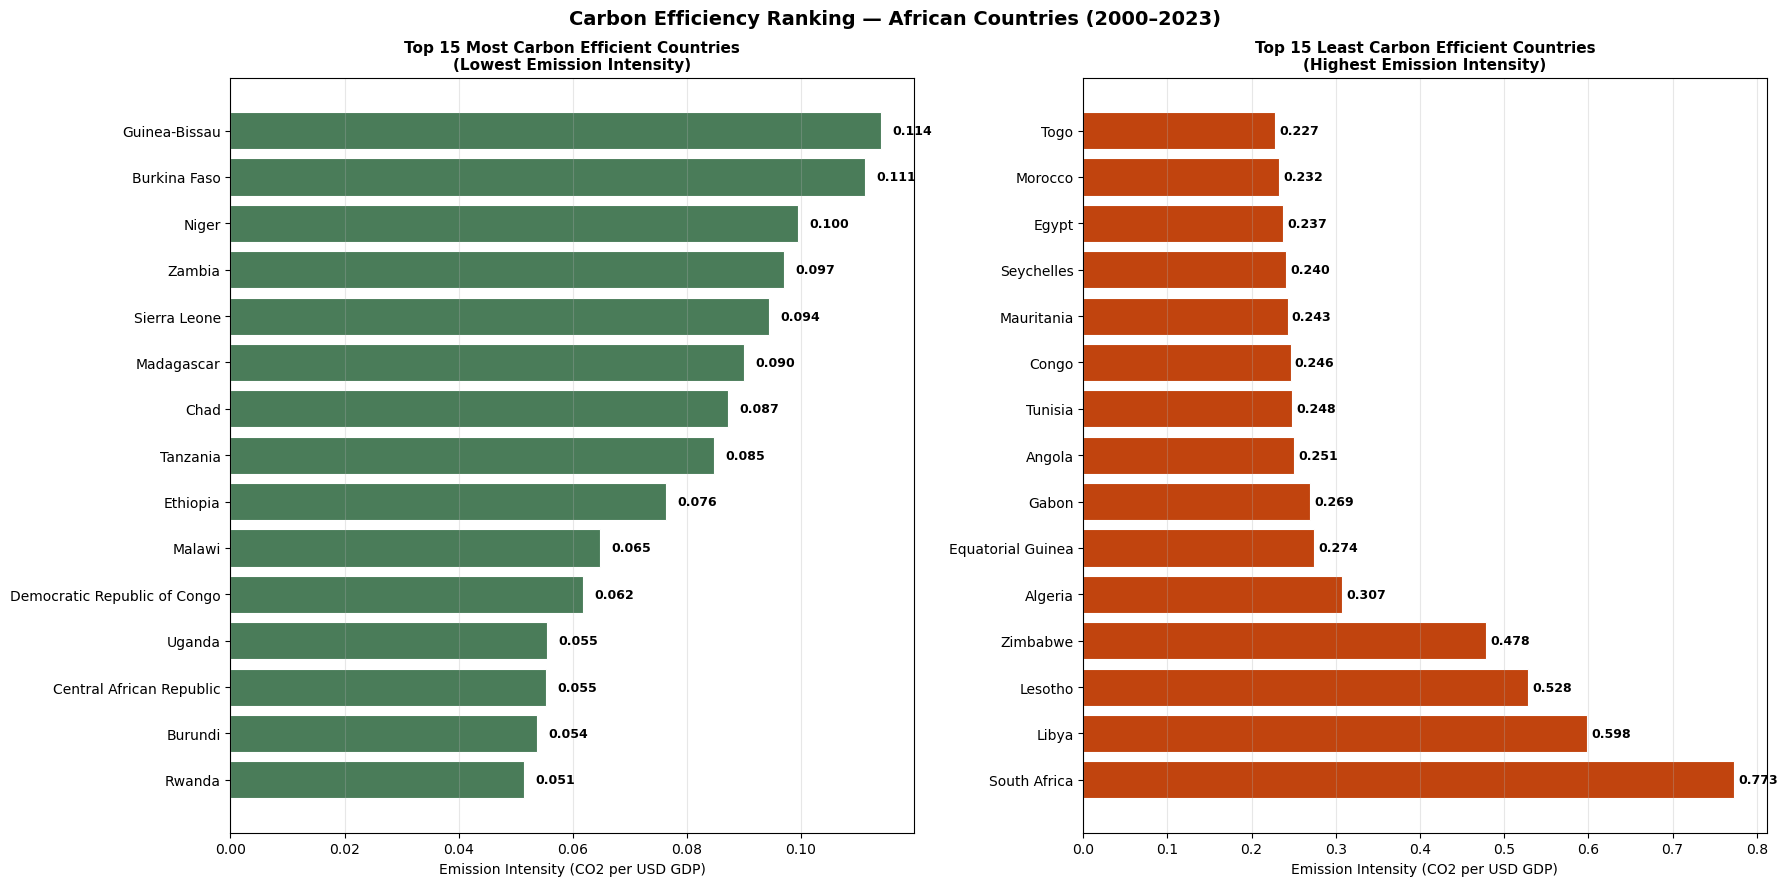

Emission intensity ranking saved!


In [17]:
# ============================================================
# STEP 13: EMISSION INTENSITY RANKING
# Rank all 52 countries from most to least carbon efficient
# ============================================================

print("="*50)
print("EMISSION INTENSITY RANKING")
print("="*50)

intensity = df.groupby('country')['co2_per_gdp'].mean()\
              .dropna().sort_values().reset_index()
intensity.columns = ['Country', 'Avg Emission Intensity']

print("Most Carbon Efficient (Top 10):")
print(intensity.head(10).round(4))
print("\nLeast Carbon Efficient (Bottom 10):")
print(intensity.tail(10).round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Most efficient
top15 = intensity.head(15)
bars1 = axes[0].barh(top15['Country'],
                      top15['Avg Emission Intensity'],
                      color='#4A7C59', edgecolor='white',
                      linewidth=0.8)
for bar, val in zip(bars1, top15['Avg Emission Intensity']):
    axes[0].text(bar.get_width() + 0.002,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}',
                va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Emission Intensity (CO2 per USD GDP)')
axes[0].set_title('Top 15 Most Carbon Efficient Countries\n(Lowest Emission Intensity)',
                  fontweight='bold', fontsize=11)
axes[0].grid(True, axis='x', alpha=0.3)

# Least efficient
bottom15 = intensity.tail(15).sort_values(
    'Avg Emission Intensity', ascending=False)
bars2 = axes[1].barh(bottom15['Country'],
                      bottom15['Avg Emission Intensity'],
                      color='#C1440E', edgecolor='white',
                      linewidth=0.8)
for bar, val in zip(bars2, bottom15['Avg Emission Intensity']):
    axes[1].text(bar.get_width() + 0.005,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}',
                va='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Emission Intensity (CO2 per USD GDP)')
axes[1].set_title('Top 15 Least Carbon Efficient Countries\n(Highest Emission Intensity)',
                  fontweight='bold', fontsize=11)
axes[1].grid(True, axis='x', alpha=0.3)

plt.suptitle('Carbon Efficiency Ranking — African Countries (2000–2023)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09_emission_intensity_ranking.png', dpi=300, bbox_inches='tight')
plt.show()
print("Emission intensity ranking saved!")

CO2 PER CAPITA ANALYSIS
              Country  Avg CO2 per Capita (t)
0               Libya                   8.998
1        South Africa                   8.119
2   Equatorial Guinea                   4.752
3          Seychelles                   4.475
4             Algeria                   3.500
5               Gabon                   3.355
6           Mauritius                   2.965
7            Botswana                   2.468
8             Tunisia                   2.433
9               Egypt                   2.209
10            Morocco                   1.608
11            Namibia                   1.370
12            Lesotho                   1.163
13              Congo                   1.154
14         Cape Verde                   0.988


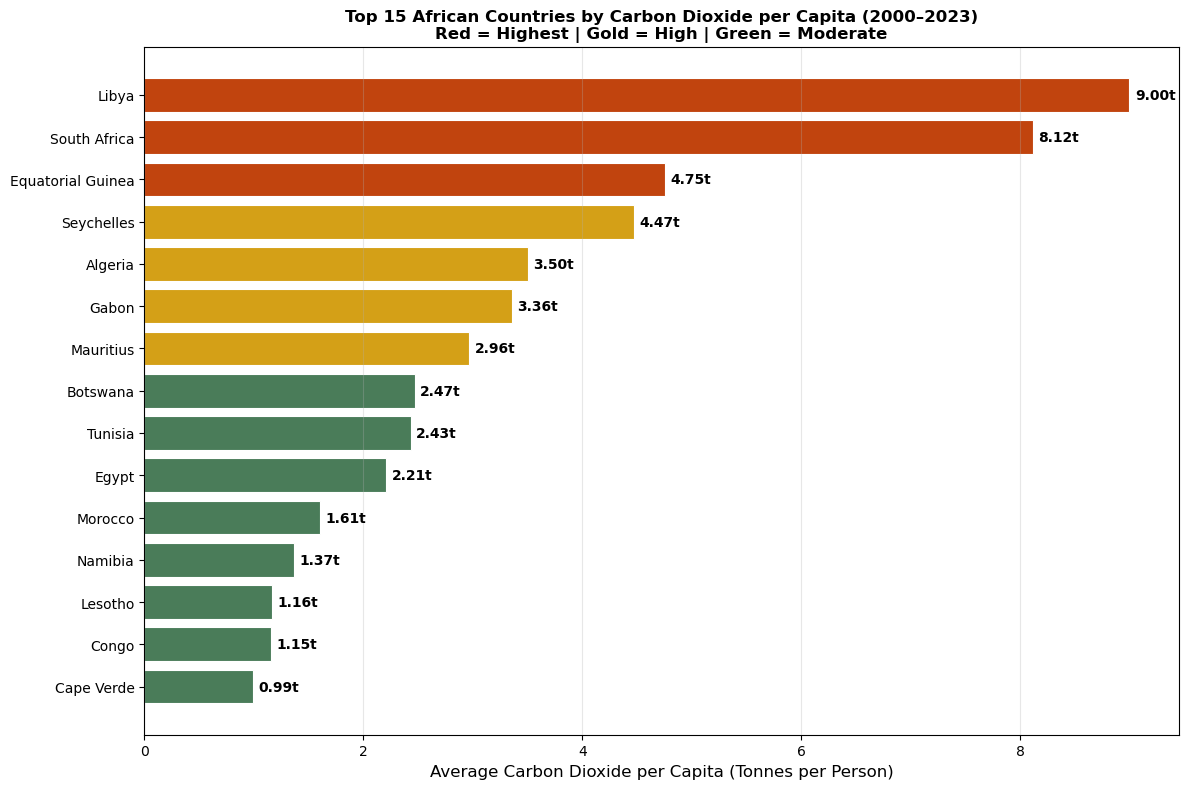

CO2 per capita chart saved!


In [18]:
# ============================================================
# STEP 14: CO2 PER CAPITA ANALYSIS
# Individual carbon footprint by country
# ============================================================

print("="*50)
print("CO2 PER CAPITA ANALYSIS")
print("="*50)

per_capita = df.groupby('country')['co2_per_capita'].mean()\
               .dropna().sort_values(ascending=False)\
               .head(15).reset_index()
per_capita.columns = ['Country', 'Avg CO2 per Capita (t)']
print(per_capita.round(3))

plt.figure(figsize=(12, 8))

bar_colors = ['#C1440E' if i < 3 else
              '#D4A017' if i < 7 else
              '#4A7C59'
              for i in range(len(per_capita))]

bars = plt.barh(per_capita['Country'][::-1],
                per_capita['Avg CO2 per Capita (t)'][::-1],
                color=bar_colors[::-1],
                edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, per_capita['Avg CO2 per Capita (t)'][::-1]):
    plt.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             f'{val:.2f}t',
             va='center', fontsize=10, fontweight='bold')

plt.xlabel('Average Carbon Dioxide per Capita (Tonnes per Person)',
           fontsize=12)
plt.title('Top 15 African Countries by Carbon Dioxide per Capita (2000–2023)\n'
          'Red = Highest | Gold = High | Green = Moderate',
          fontsize=12, fontweight='bold')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('10_co2_per_capita.png', dpi=300, bbox_inches='tight')
plt.show()
print("CO2 per capita chart saved!")

In [19]:
# ============================================================
# STEP 15: FINAL SUMMARY
# Print all key statistical findings in one place
# This goes directly into your report
# ============================================================

# Recalculate key stats
gdp_co2_clean = df[['gdp', 'co2']].dropna()
r, p = stats.pearsonr(gdp_co2_clean['gdp'], gdp_co2_clean['co2'])

yearly_clean = df.groupby('year')['co2'].mean()
co2_pct_change = ((yearly_clean.iloc[-1] - yearly_clean.iloc[0]) /
                   yearly_clean.iloc[0] * 100)

yearly_gdp = df.groupby('year')['gdp'].mean().dropna()
gdp_pct_change = ((yearly_gdp.iloc[-1] - yearly_gdp.iloc[0]) /
                   yearly_gdp.iloc[0] * 100)

most_efficient = df.groupby('country')['co2_per_gdp']\
                   .mean().idxmin()
least_efficient = df.groupby('country')['co2_per_gdp']\
                    .mean().idxmax()
top_emitter = df.groupby('country')['co2'].mean().idxmax()
top_flaring = df.groupby('country')['flaring_co2'].mean().idxmax()
top_methane = df.groupby('country')['methane'].mean().idxmax()

print("="*60)
print("PYTHON ANALYSIS — FINAL SUMMARY REPORT")
print("Growth at What Cost? CO2 Africa Project")
print("="*60)

print(f"""
DATASET INFORMATION:
  Countries Analysed:          {df['country'].nunique()}
  Total Observations:          {len(df)}
  Time Period:                 {df['year'].min()} to {df['year'].max()}

EMISSION OVERVIEW:
  Average CO2 per Country:     {df['co2'].mean():.2f} million tonnes
  Highest CO2 Country:         {top_emitter}
  Maximum CO2 Recorded:        {df['co2'].max():.2f} million tonnes
  Minimum CO2 Recorded:        {df['co2'].min():.3f} million tonnes

ECONOMIC OVERVIEW:
  Average GDP per Country:     ${df['gdp'].mean()/1e9:.2f} billion USD

GROWTH COMPARISON (2000-2023):
  Total CO2 Growth:            {co2_pct_change:.1f}%
  Total GDP Growth:            {gdp_pct_change:.1f}%
  GDP grew faster than CO2:    {'YES' if gdp_pct_change > co2_pct_change else 'NO'}
  Decoupling Confirmed:        {'YES' if gdp_pct_change > co2_pct_change else 'NO'}

CORE STATISTICAL TEST:
  Pearson Correlation (r):     {r:.4f}
  P-value:                     {p:.6f}
  Statistically Significant:   {'YES (p < 0.05)' if p < 0.05 else 'NO (p > 0.05)'}
  Correlation Strength:        {'Strong' if abs(r) > 0.7 else 'Moderate' if abs(r) > 0.4 else 'Weak'}

EFFICIENCY ANALYSIS:
  Most Carbon Efficient:       {most_efficient}
  Least Carbon Efficient:      {least_efficient}
  Continental Avg Intensity:   {df['co2_per_gdp'].mean():.4f} tonnes per USD

SECTORAL HIGHLIGHTS:
  Top Gas Flaring Nation:      {top_flaring}
  Top Methane Emitter:         {top_methane}

CHARTS SAVED (10 files):
  01_missing_values_heatmap.png
  02_outlier_detection_boxplots.png
  03_correlation_heatmap.png
  04_gdp_vs_co2_scatter.png
  05_trend_analysis.png
  06_top_emitters.png
  07_regional_comparison.png
  08_decoupling_analysis.png
  09_emission_intensity_ranking.png
  10_co2_per_capita.png
""")

# Save summary to text file
with open('python_final_summary.txt', 'w') as f:
    f.write(f"""PYTHON ANALYSIS SUMMARY
Growth at What Cost — CO2 Africa Project

Countries: {df['country'].nunique()}
Observations: {len(df)}
Period: {df['year'].min()} to {df['year'].max()}

Pearson Correlation (r): {r:.4f}
P-value: {p:.6f}
Statistically Significant: {'YES' if p < 0.05 else 'NO'}

CO2 Growth (2000-2023): {co2_pct_change:.1f}%
GDP Growth (2000-2023): {gdp_pct_change:.1f}%

Most Efficient Country: {most_efficient}
Least Efficient Country: {least_efficient}
Top Emitter: {top_emitter}
Top Flaring Nation: {top_flaring}
""")

print("Summary saved to python_final_summary.txt")
print("\nPYTHON ANALYSIS COMPLETE!")
print("All 10 charts and summary file saved in your project folder.")

PYTHON ANALYSIS — FINAL SUMMARY REPORT
Growth at What Cost? CO2 Africa Project

DATASET INFORMATION:
  Countries Analysed:          52
  Total Observations:          1248
  Time Period:                 2000 to 2023

EMISSION OVERVIEW:
  Average CO2 per Country:     23.36 million tonnes
  Highest CO2 Country:         South Africa
  Maximum CO2 Recorded:        494.70 million tonnes
  Minimum CO2 Recorded:        0.048 million tonnes

ECONOMIC OVERVIEW:
  Average GDP per Country:     $91.13 billion USD

GROWTH COMPARISON (2000-2023):
  Total CO2 Growth:            52.2%
  Total GDP Growth:            200.6%
  GDP grew faster than CO2:    YES
  Decoupling Confirmed:        YES

CORE STATISTICAL TEST:
  Pearson Correlation (r):     0.7712
  P-value:                     0.000000
  Statistically Significant:   YES (p < 0.05)
  Correlation Strength:        Strong

EFFICIENCY ANALYSIS:
  Most Carbon Efficient:       Rwanda
  Least Carbon Efficient:      South Africa
  Continental Avg Intensity